In [1]:
!pip install kagglehub


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prachi13/customer-analytics")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\AISHWARYA.GAJULA\.cache\kagglehub\datasets\prachi13\customer-analytics\versions\1


In [3]:
import os

dataset_path = r"C:\Users\AISHWARYA.GAJULA\.cache\kagglehub\datasets\prachi13\customer-analytics\versions\1"

print(os.listdir(dataset_path))


['Train.csv']


In [4]:
import pandas as pd


df = pd.read_csv(os.path.join(dataset_path, "Train.csv"))

 


In [5]:
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [6]:
print(df.head())   


   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44           1233            

In [7]:
print(df.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB
None


In [8]:
print(df.columns)

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')


In [9]:
print(df.describe())

                ID  Customer_care_calls  Customer_rating  Cost_of_the_Product  \
count  10999.00000         10999.000000     10999.000000         10999.000000   
mean    5500.00000             4.054459         2.990545           210.196836   
std     3175.28214             1.141490         1.413603            48.063272   
min        1.00000             2.000000         1.000000            96.000000   
25%     2750.50000             3.000000         2.000000           169.000000   
50%     5500.00000             4.000000         3.000000           214.000000   
75%     8249.50000             5.000000         4.000000           251.000000   
max    10999.00000             7.000000         5.000000           310.000000   

       Prior_purchases  Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
count     10999.000000      10999.000000   10999.000000         10999.000000  
mean          3.567597         13.373216    3634.016729             0.596691  
std           1.522860         16

In [10]:
print(df.isnull().sum())

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [11]:
 #Unique Values in Each Column 
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

ID: 10999 unique values
Warehouse_block: 5 unique values
Mode_of_Shipment: 3 unique values
Customer_care_calls: 6 unique values
Customer_rating: 5 unique values
Cost_of_the_Product: 215 unique values
Prior_purchases: 8 unique values
Product_importance: 3 unique values
Gender: 2 unique values
Discount_offered: 65 unique values
Weight_in_gms: 4034 unique values
Reached.on.Time_Y.N: 2 unique values


In [12]:
if "Gender" in df.columns:
    print(df["Gender"].unique())

['F' 'M']


In [13]:
#Count deliveries reached on time vs not
print(df["Reached.on.Time_Y.N"].value_counts())

1    6563
0    4436
Name: Reached.on.Time_Y.N, dtype: int64


In [14]:
# Average cost of product for late deliveries
print(df[df["Reached.on.Time_Y.N"] == 0]["Cost_of_the_Product"].mean())

214.49864743011722


In [15]:
print(df.groupby("Mode_of_Shipment")["Discount_offered"].max())

Mode_of_Shipment
Flight    65
Road      65
Ship      65
Name: Discount_offered, dtype: int64


In [16]:
df["Cost_After_Discount"] = df["Cost_of_the_Product"] - df["Discount_offered"]
print(df[["Cost_of_the_Product", "Discount_offered", "Cost_After_Discount"]].head())


   Cost_of_the_Product  Discount_offered  Cost_After_Discount
0                  177                44                  133
1                  216                59                  157
2                  183                48                  135
3                  176                10                  166
4                  184                46                  138


In [17]:
#  Top 5 heaviest products
print(df.sort_values(by="Weight_in_gms", ascending=False).head())

      ID Warehouse_block Mode_of_Shipment  Customer_care_calls  \
199  200               F             Ship                    2   
245  246               F             Ship                    2   
198  199               D             Ship                    2   
205  206               F             Ship                    2   
213  214               B             Ship                    2   

     Customer_rating  Cost_of_the_Product  Prior_purchases Product_importance  \
199                2                  154                3             medium   
245                4                  154                3             medium   
198                3                  142                3             medium   
205                3                  145                3             medium   
213                5                  160                3             medium   

    Gender  Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  \
199      M                38           7846     

In [18]:
#  Percentage of on-time deliveries
on_time_rate = (df["Reached.on.Time_Y.N"].value_counts(normalize=True) * 100)
print(on_time_rate)

1    59.669061
0    40.330939
Name: Reached.on.Time_Y.N, dtype: float64


In [19]:
#Pivot table: Avg Discount by Warehouse block & Delivery status
print(df.pivot_table(values="Discount_offered", index="Warehouse_block", columns="Reached.on.Time_Y.N", aggfunc="mean"))

Reached.on.Time_Y.N         0          1
Warehouse_block                         
A                    5.526385  18.649302
B                    5.577503  18.211957
C                    5.430311  18.783364
D                    5.604336  18.136861
F                    5.569293  19.101641


In [20]:
# 39.   pivot table of Avg Cost_of_the_Product by Gender, Mode_of_Shipment, and Delivery status
print(df.pivot_table(values="Cost_of_the_Product", index=["Gender", "Mode_of_Shipment"], columns="Reached.on.Time_Y.N", aggfunc="mean"))

Reached.on.Time_Y.N               0           1
Gender Mode_of_Shipment                        
F      Flight            214.812500  205.408745
       Road              216.106952  205.434457
       Ship              213.241715  206.347048
M      Flight            212.139785  207.734807
       Road              214.635328  208.730539
       Ship              215.903689  208.693657


In [21]:
#   Warehouse block with  highest avg delivery delay rate
print(df.groupby("Warehouse_block")["Reached.on.Time_Y.N"].value_counts(normalize=True).unstack().fillna(0))

Reached.on.Time_Y.N         0         1
Warehouse_block                        
A                    0.413530  0.586470
B                    0.397709  0.602291
C                    0.403164  0.596836
D                    0.402399  0.597601
F                    0.401528  0.598472


In [22]:
# Comparing Customer rating distribution between on-time and late deliveries
print(df.groupby("Reached.on.Time_Y.N")["Customer_rating"].value_counts(normalize=True))

Reached.on.Time_Y.N  Customer_rating
0                    1                  0.207845
                     2                  0.201082
                     4                  0.199729
                     3                  0.198828
                     5                  0.192516
1                    3                  0.206765
                     5                  0.200670
                     1                  0.200061
                     4                  0.198537
                     2                  0.193966
Name: Customer_rating, dtype: float64


In [23]:
# factors correlate most with on-time delivery 
correlations = df.corr(numeric_only=True)["Reached.on.Time_Y.N"].sort_values(ascending=False)
print(correlations)

Reached.on.Time_Y.N    1.000000
Discount_offered       0.397108
Customer_rating        0.013119
Prior_purchases       -0.055515
Customer_care_calls   -0.067126
Cost_of_the_Product   -0.073587
Cost_After_Discount   -0.188857
Weight_in_gms         -0.268793
ID                    -0.411822
Name: Reached.on.Time_Y.N, dtype: float64


In [24]:
#  Using lambda  creating new feature "Final_Price" = Cost - Discount
df = df.assign(Final_Price=lambda x: x["Cost_of_the_Product"] - x["Discount_offered"])
print(df[["Cost_of_the_Product", "Discount_offered", "Final_Price"]].head())

   Cost_of_the_Product  Discount_offered  Final_Price
0                  177                44          133
1                  216                59          157
2                  183                48          135
3                  176                10          166
4                  184                46          138


In [25]:
cost_impact = df.groupby("Reached.on.Time_Y.N").apply(
    lambda g: (g["Cost_of_the_Product"] - g["Discount_offered"]).mean()
)
print("Avg Final Price (On-time=1, Late=0):\n", cost_impact)

Avg Final Price (On-time=1, Late=0):
 Reached.on.Time_Y.N
0    208.952660
1    188.625476
dtype: float64


In [26]:

shipment_eff = df.groupby("Mode_of_Shipment").apply(
    lambda g: (g["Reached.on.Time_Y.N"] == 1).mean() * 100
)
print("Late Delivery % by Shipment Mode:\n", shipment_eff)

Late Delivery % by Shipment Mode:
 Mode_of_Shipment
Flight    60.157569
Road      58.806818
Ship      59.756098
dtype: float64


In [27]:

shipment_eff = df.groupby("Mode_of_Shipment").apply(
    lambda g: (g["Reached.on.Time_Y.N"] == 0).mean() * 100
)
print("on_Time Delivery % by Shipment Mode:\n", shipment_eff)

on_Time Delivery % by Shipment Mode:
 Mode_of_Shipment
Flight    39.842431
Road      41.193182
Ship      40.243902
dtype: float64


In [28]:

gender_spending = df.groupby("Gender").apply(
    lambda g: (g["Cost_of_the_Product"] - g["Discount_offered"]).mean()
)
print("Avg Spending by Gender:\n", gender_spending)

Avg Spending by Gender:
 Gender
F    195.692516
M    197.973597
dtype: float64


In [29]:

df["Profit"] = df.apply(lambda x: (x["Cost_of_the_Product"] - x["Discount_offered"]) - (0.1 * x["Discount_offered"]), axis=1)
profitability = df.groupby("Mode_of_Shipment").apply(lambda g: g["Profit"].mean())
print("Avg Profit by Shipment Mode:\n", profitability)

Avg Profit by Shipment Mode:
 Mode_of_Shipment
Flight    194.829657
Road      196.083068
Ship      195.501916
dtype: float64


In [30]:
# Crosstab analysis... Relation between Shipment Mode & On-Time Delivery
shipment_vs_delivery = pd.crosstab(df["Mode_of_Shipment"], df["Reached.on.Time_Y.N"], normalize="index") * 100
print(" Shipment mode vs On-time delivery %:\n", shipment_vs_delivery, "\n")

 Shipment mode vs On-time delivery %:
 Reached.on.Time_Y.N          0          1
Mode_of_Shipment                         
Flight               39.842431  60.157569
Road                 41.193182  58.806818
Ship                 40.243902  59.756098 



In [31]:
#   fraud possibilities→ Customers with very high discount & still delivered late
possible_fraud = df[(df["Discount_offered"] > df["Discount_offered"].quantile(0.95)) & (df["Reached.on.Time_Y.N"] == 1)]
print(" Possible fraud cases:\n", possible_fraud[["ID", "Discount_offered", "Reached.on.Time_Y.N"]].head(), "\n")

 Possible fraud cases:
     ID  Discount_offered  Reached.on.Time_Y.N
1    2                59                    1
31  32                61                    1
36  37                62                    1
38  39                56                    1
41  42                61                    1 



In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox, norm, bernoulli, binom, poisson, geom, uniform, expon, chi2, f, t, lognorm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

In [33]:
print("Dataset Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDescriptive Stats:\n", df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10999 non-null  int64  
 1   Warehouse_block      10999 non-null  object 
 2   Mode_of_Shipment     10999 non-null  object 
 3   Customer_care_calls  10999 non-null  int64  
 4   Customer_rating      10999 non-null  int64  
 5   Cost_of_the_Product  10999 non-null  int64  
 6   Prior_purchases      10999 non-null  int64  
 7   Product_importance   10999 non-null  object 
 8   Gender               10999 non-null  object 
 9   Discount_offered     10999 non-null  int64  
 10  Weight_in_gms        10999 non-null  int64  
 11  Reached.on.Time_Y.N  10999 non-null  int64  
 12  Cost_After_Discount  10999 non-null  int64  
 13  Final_Price          10999 non-null  int64  
 14  Profit               10999 non-null  float64
dtypes: float64(1), int64(1

In [34]:
# Skewness
print("\nSkewness:\n", df.skew(numeric_only=True))


Skewness:
 ID                     0.000000
Customer_care_calls    0.391926
Customer_rating        0.004360
Cost_of_the_Product   -0.157117
Prior_purchases        1.681897
Discount_offered       1.798929
Weight_in_gms         -0.249747
Reached.on.Time_Y.N   -0.394257
Cost_After_Discount   -0.219861
Final_Price           -0.219861
Profit                -0.238039
dtype: float64


In [36]:
 # Kurtosis
print("\nKurtosis:\n", df.kurt(numeric_only=True))


Kurtosis:
 ID                    -1.200000
Customer_care_calls   -0.308995
Customer_rating       -1.295654
Cost_of_the_Product   -0.972160
Prior_purchases        4.006342
Discount_offered       2.000586
Weight_in_gms         -1.447671
Reached.on.Time_Y.N   -1.844897
Cost_After_Discount   -0.777233
Final_Price           -0.777233
Profit                -0.739086
dtype: float64


In [70]:
for col in ["Cost_of_the_Product", "Discount_offered", "Weight_in_gms"]:
    print(f"{col}: Skewness={skew(df[col])}, Kurtosis={kurtosis(df[col])}")

NameError: name 'skew' is not defined

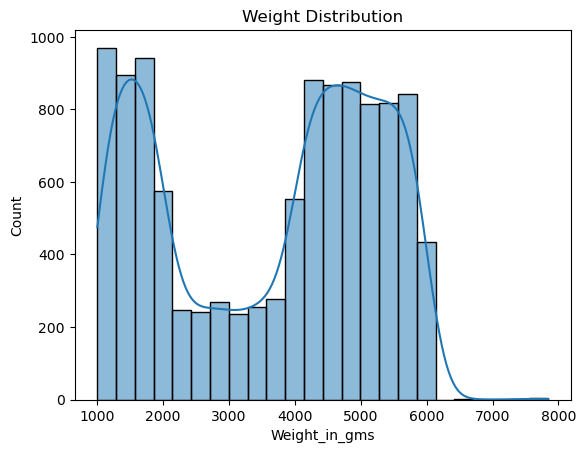

In [37]:
# Univariate plots
sns.histplot(df["Weight_in_gms"], kde=True)
plt.title("Weight Distribution")
plt.show()

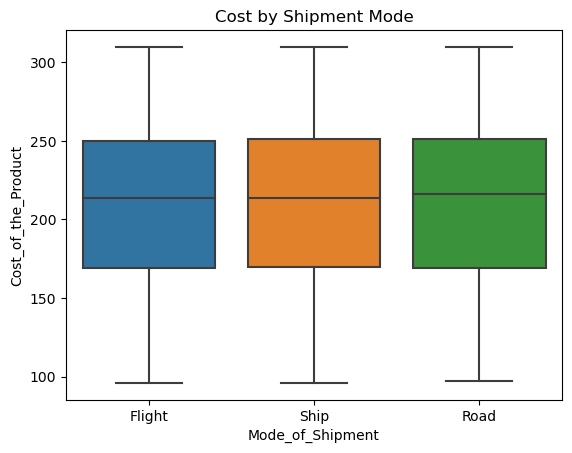

In [38]:
# Multivariate plots
sns.boxplot(x="Mode_of_Shipment", y="Cost_of_the_Product", data=df)
plt.title("Cost by Shipment Mode")
plt.show()

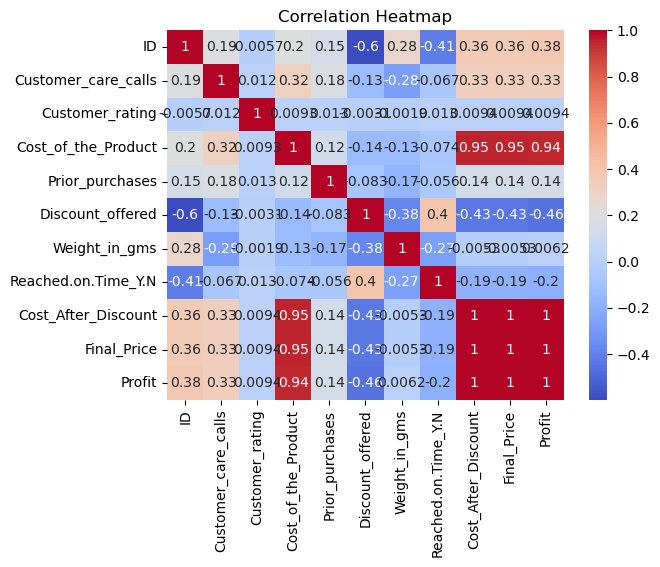

In [39]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [40]:
# Descriptive Analytics
desc_stats = df[["Weight_in_gms", "Cost_of_the_Product", "Discount_offered"]].describe()
print("\nDescriptive Analytics:\n", desc_stats)


Descriptive Analytics:
        Weight_in_gms  Cost_of_the_Product  Discount_offered
count   10999.000000         10999.000000      10999.000000
mean     3634.016729           210.196836         13.373216
std      1635.377251            48.063272         16.205527
min      1001.000000            96.000000          1.000000
25%      1839.500000           169.000000          4.000000
50%      4149.000000           214.000000          7.000000
75%      5050.000000           251.000000         10.000000
max      7846.000000           310.000000         65.000000


In [41]:
# Predictive Analytics___to_Predict if shipment is delayed
X = df[["Weight_in_gms", "Cost_of_the_Product", "Discount_offered", "Customer_rating"]]
y = df["Reached.on.Time_Y.N"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [42]:
print("\nPredictive Analytics - Logistic Regression Report:")
print(classification_report(y_test, y_pred))


Predictive Analytics - Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.53      0.58      0.55      1312
           1       0.70      0.66      0.68      1988

    accuracy                           0.63      3300
   macro avg       0.62      0.62      0.62      3300
weighted avg       0.64      0.63      0.63      3300



In [43]:
# Prescriptive Analytics: Recommend shipment mode based on profit
df["Profit"] = (df["Cost_of_the_Product"] - df["Discount_offered"]) - (0.1 * df["Discount_offered"])
mode_profit = df.groupby("Mode_of_Shipment")["Profit"].mean().sort_values(ascending=False)
print("\nPrescriptive Recommendation - Best Mode of Shipment:\n", mode_profit)


Prescriptive Recommendation - Best Mode of Shipment:
 Mode_of_Shipment
Road      196.083068
Ship      195.501916
Flight    194.829657
Name: Profit, dtype: float64


In [44]:
#Transformation Techniques

In [45]:
# Outlier Treatment using IQR
Q1 = df["Cost_of_the_Product"].quantile(0.25)
Q3 = df["Cost_of_the_Product"].quantile(0.75)
IQR = Q3 - Q1
df_outlier_treated = df[~((df["Cost_of_the_Product"] < (Q1 - 1.5 * IQR)) | 
                          (df["Cost_of_the_Product"] > (Q3 + 1.5 * IQR)))]

In [48]:
df_outlier_treated

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Cost_After_Discount,Final_Price,Profit
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,133,133,128.6
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,157,157,151.1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,135,135,130.2
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,166,166,165.0
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,138,138,133.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1,251,251,250.9
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0,226,226,225.4
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0,238,238,237.6
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0,221,221,220.8


In [46]:
# Log Transformation
df["Log_Cost"] = np.log1p(df["Cost_of_the_Product"])

In [47]:
df["Log_Cost"]

0        5.181784
1        5.379897
2        5.214936
3        5.176150
4        5.220356
           ...   
10994    5.533389
10995    5.451038
10996    5.493061
10997    5.411646
10998    5.049856
Name: Log_Cost, Length: 10999, dtype: float64

In [49]:
df["Exp_Cost"] = np.exp(df["Cost_of_the_Product"]/df["Cost_of_the_Product"].max())
df["Exp_Cost"]

0        1.769979
1        2.007267
2        1.804570
3        1.764279
4        1.810401
           ...   
10994    2.254444
10995    2.113588
10996    2.182880
10997    2.053108
10998    1.648721
Name: Exp_Cost, Length: 10999, dtype: float64

In [50]:
# Reciprocal Transformation
df["Recip_Cost"] = np.reciprocal(df["Cost_of_the_Product"])
df["Recip_Cost"] 

0        0
1        0
2        0
3        0
4        0
        ..
10994    0
10995    0
10996    0
10997    0
10998    0
Name: Recip_Cost, Length: 10999, dtype: int64

In [51]:
# Box-Cox (only positive values)
df["BoxCox_Weight"], _ = boxcox(df["Weight_in_gms"] + 1)
df["BoxCox_Weight"]

0         805.273199
1        1891.890898
2        2054.379951
3         771.185819
4        1545.114413
            ...     
10994     989.151354
10995     813.777949
10996     757.763588
10997     791.286409
10998    1049.454415
Name: BoxCox_Weight, Length: 10999, dtype: float64

In [53]:
p_on_time = np.mean(df["Reached.on.Time_Y.N"] == 1)
p_high_discount = np.mean(df["Discount_offered"] > 5)
p_conditional = np.mean((df["Reached.on.Time_Y.N"] == 1) & (df["Discount_offered"] > 5)) / p_high_discount
print(f"\nP(OnTime): {p_on_time}, P(HighDiscount): {p_high_discount}, P(OnTime | HighDiscount): {p_conditional}")

# Bayes Theorem Example
# P(OnTime | HighDiscount) * P(HighDiscount) / P(OnTime)
bayes_prob = (p_conditional * p_high_discount) / p_on_time
print("Bayes Probability Example:", bayes_prob)


P(OnTime): 0.5966906082371125, P(HighDiscount): 0.6220565505955087, P(OnTime | HighDiscount): 0.6711487869044139
Bayes Probability Example: 0.6996800243790948


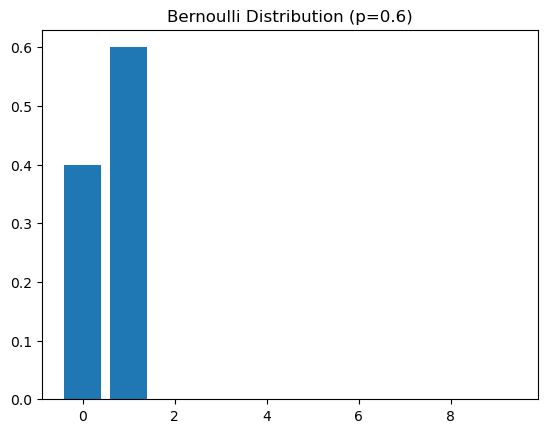

In [55]:
plt.bar(x, bernoulli.pmf(x, 0.6))
plt.title("Bernoulli Distribution (p=0.6)")
plt.show()

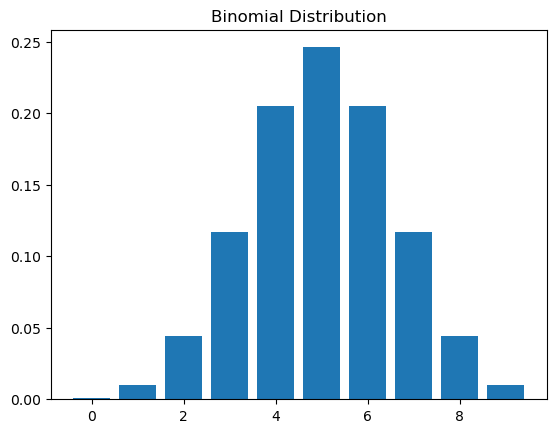

In [56]:
plt.bar(x, binom.pmf(x, 10, 0.5))
plt.title("Binomial Distribution")
plt.show()

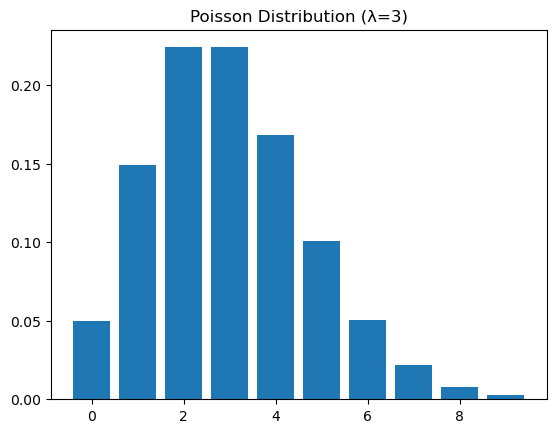

In [57]:
plt.bar(x, poisson.pmf(x, 3))
plt.title("Poisson Distribution (λ=3)")
plt.show()

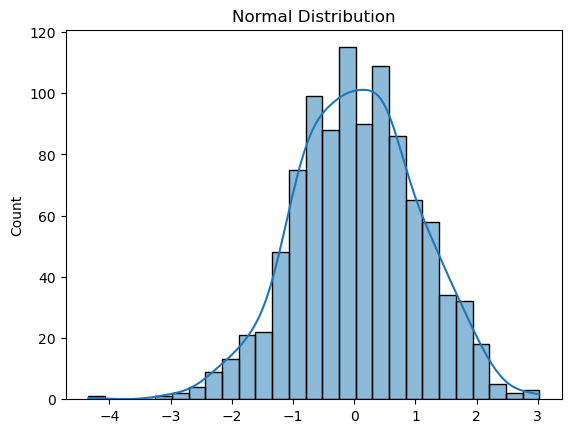

In [58]:
sns.histplot(norm.rvs(size=1000), kde=True)
plt.title("Normal Distribution")
plt.show()

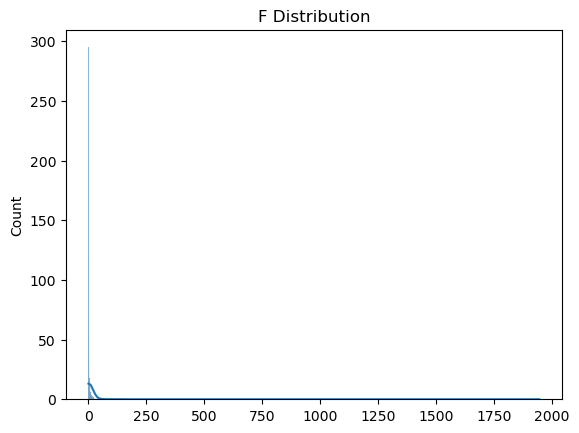

In [59]:
sns.histplot(f.rvs(5, 2, size=1000), kde=True)
plt.title("F Distribution")
plt.show()


In [60]:
# Interpolation
df["Weight_in_gms"] = df["Weight_in_gms"].interpolate()

In [61]:
df["Weight_in_gms"]

0        1233
1        3088
2        3374
3        1177
4        2484
         ... 
10994    1538
10995    1247
10996    1155
10997    1210
10998    1639
Name: Weight_in_gms, Length: 10999, dtype: int64

In [64]:
# Create Customer Value Index
df["Customer_Value_Index"] = (df["Customer_rating"] * df["Cost_of_the_Product"]) / (df["Discount_offered"] + 1)

In [65]:
df["Customer_Value_Index"] 

0          7.866667
1         18.000000
2          7.469388
3         48.000000
4          7.829787
            ...    
10994    126.000000
10995     33.142857
10996    193.600000
10997    148.666667
10998    110.714286
Name: Customer_Value_Index, Length: 10999, dtype: float64

In [67]:
# Profit Margin Ratio
df["Profit_Margin_Ratio"] = df["Profit"] / df["Cost_of_the_Product"]
df["Profit_Margin_Ratio"] 

0        0.726554
1        0.699537
2        0.711475
3        0.937500
4        0.725000
           ...   
10994    0.995635
10995    0.971552
10996    0.981818
10997    0.990135
10998    0.957419
Name: Profit_Margin_Ratio, Length: 10999, dtype: float64

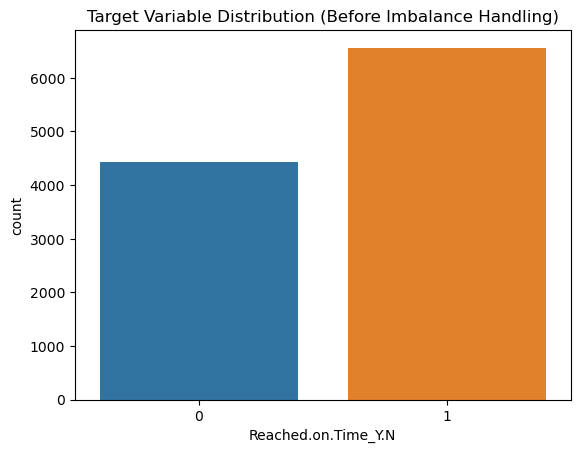

In [68]:
# Distribution of Target Variable
sns.countplot(x="Reached.on.Time_Y.N", data=df)
plt.title("Target Variable Distribution (Before Imbalance Handling)")
plt.show()

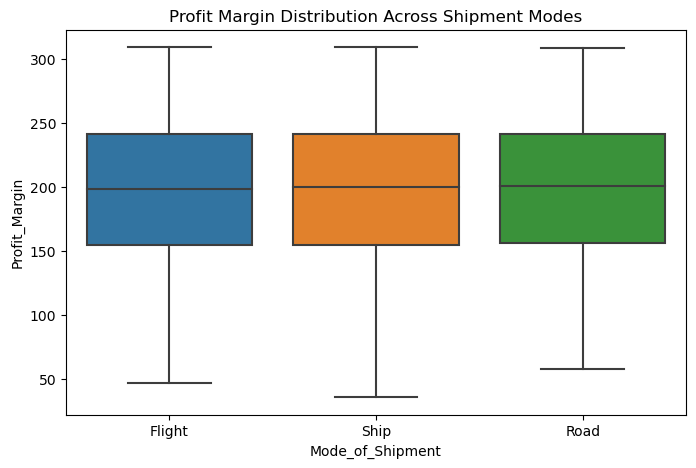

In [72]:
# Profit Margin = Cost - Discount (simple proxy)
df["Profit_Margin"] = df["Cost_of_the_Product"] - df["Discount_offered"]


# Compare profit margin across shipment modes
plt.figure(figsize=(8,5))
sns.boxplot(x="Mode_of_Shipment", y="Profit_Margin", data=df)
plt.title("Profit Margin Distribution Across Shipment Modes")
plt.show()

In [73]:
profit_mode = df.groupby("Mode_of_Shipment")["Profit_Margin"].mean()
print("\nFeature Insight - Average Profit Margin per Shipment Mode:\n", profit_mode)


Feature Insight - Average Profit Margin per Shipment Mode:
 Mode_of_Shipment
Flight    196.145751
Road      197.391477
Ship      196.851112
Name: Profit_Margin, dtype: float64


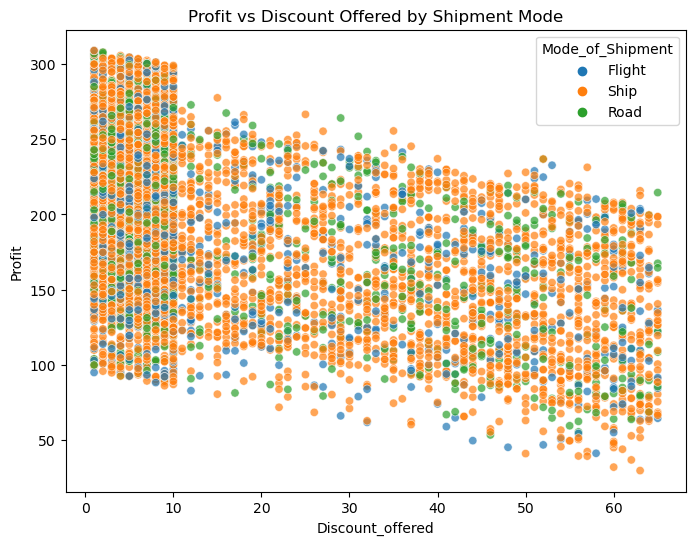

In [75]:
#whether high discounts reduce profitability across different shipment types.
plt.figure(figsize=(8,6))
sns.scatterplot(x="Discount_offered", y="Profit", hue="Mode_of_Shipment", data=df, alpha=0.7)
plt.title("Profit vs Discount Offered by Shipment Mode")
plt.show()


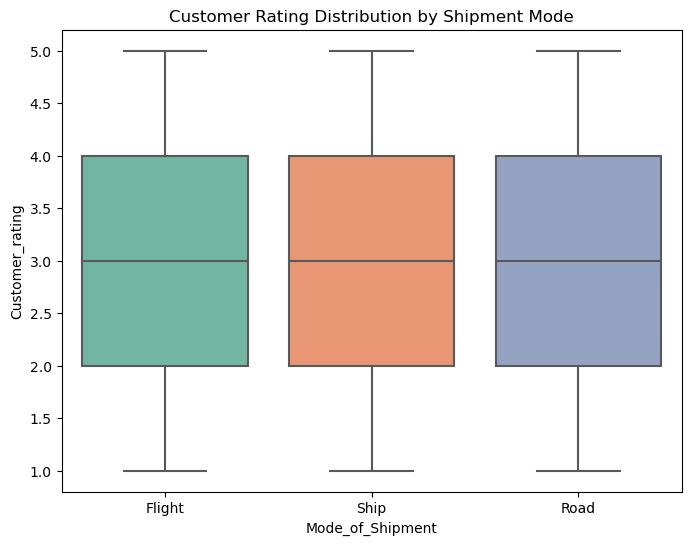

In [76]:
#if some shipment modes have consistently lower/higher customer ratings.
plt.figure(figsize=(8,6))
sns.boxplot(x="Mode_of_Shipment", y="Customer_rating", data=df, palette="Set2")
plt.title("Customer Rating Distribution by Shipment Mode")
plt.show()


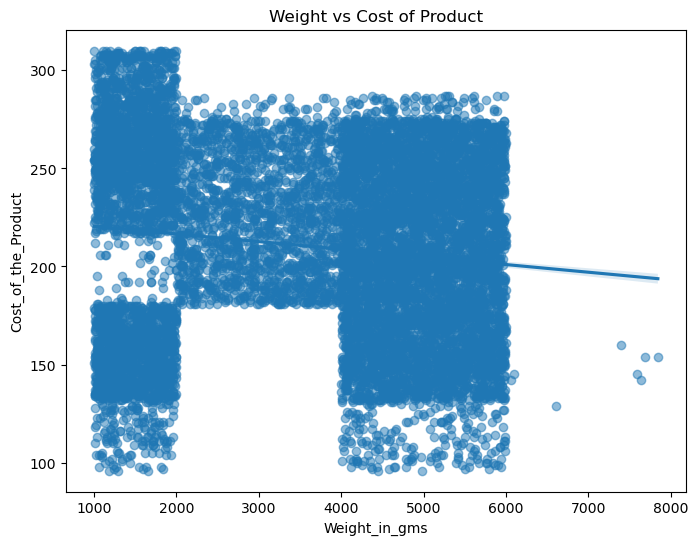

In [77]:
#correlation between product weight and cost.
plt.figure(figsize=(8,6))
sns.regplot(x="Weight_in_gms", y="Cost_of_the_Product", data=df, scatter_kws={'alpha':0.5})
plt.title("Weight vs Cost of Product")
plt.show()
